<h1 style="color:#56B4E9;">Week 8 — Day 3</h1>

<h2 style="color:#0072B2;">Computer Vision Preprocessing with OpenCV</h2>

### Oxford-IIIT Pet Image Classification

Day 3 introduces the preprocessing steps required before images can be used by computer-vision and transfer-learning models.

The notebook uses the Oxford-IIIT Pet dataset, which contains images of 37 cat and dog breeds with natural variations in image size, lighting, scale, background, and pose.

<h2 style="color:#0072B2;">Learning Objectives</h2>

In this notebook, we will gradually learn to:

- Read and inspect images using OpenCV.
- Understand how images are represented as numerical arrays.
- Standardize different image sizes.
- Convert images from BGR to RGB.
- Normalize pixel values.
- Build a reusable image-preprocessing function.
- Create and visualize an image-augmentation pipeline.
- Match preprocessing to a pretrained transfer-learning model.

<h2 style="color:#0072B2;">3.1 Why Images Need Preprocessing</h2>

Raw images cannot be passed directly to a machine-learning model because they may differ in:

- Width and height.
- Color-channel ordering.
- Pixel-value ranges.
- Lighting and image quality.
- Scale, pose, and background.

An RGB image is represented as a three-dimensional array:

$$
\text{Image Shape}
=
(\text{Height},\text{Width},\text{Channels})
$$

For example:

$$
(300, 500, 3)
$$

means that the image has 300 rows, 500 columns, and three color channels.

A model expects every image in one batch to have the same shape and numerical scale. Therefore, preprocessing converts different raw images into a consistent model-ready representation.

In [1]:
%pip install -q opencv-python

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.utils import get_file

RANDOM_STATE = 42
TARGET_SIZE = (224, 224)

print("OpenCV version:", cv2.__version__)
print("Target image size:", TARGET_SIZE)

I0000 00:00:1788885877.892379  209551 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788885877.898527  209551 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788885878.972713  209551 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788885887.079746  209551 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

OpenCV version: 5.0.0
Target image size: (224, 224)


<h2 style="color:#0072B2;">3.2 Loading the Oxford-IIIT Pet Dataset</h2>

The dataset contains images of 37 cat and dog breeds. The images have different dimensions, poses, lighting conditions, and backgrounds, making them suitable for studying image standardization.

Only the image archive is downloaded at this stage. The current goal is preprocessing and inspection, not model training.

In [4]:
DATA_DIRECTORY = Path("data/oxford_iiit_pet").resolve()

archive_path = Path(
    get_file(
        fname="images.tar.gz",
        origin="https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz",
        extract=True,
        cache_dir=str(DATA_DIRECTORY.parent),
        cache_subdir=DATA_DIRECTORY.name,
    )
)

# Keras versions may return either the archive path
# or a separate extracted directory.
search_root = (
    archive_path
    if archive_path.is_dir()
    else archive_path.parent
)

image_paths = sorted(search_root.rglob("*.jpg"))

assert len(image_paths) > 0, (
    f"No JPG images were found under: {search_root}"
)

IMAGE_DIRECTORY = image_paths[0].parent

print("Returned path:", archive_path)
print("Search root:", search_root)
print("Image directory:", IMAGE_DIRECTORY)
print("Number of image files:", len(image_paths))

Returned path: /tmp/.keras/oxford_iiit_pet/images_extracted
Search root: /tmp/.keras/oxford_iiit_pet/images_extracted
Image directory: /tmp/.keras/oxford_iiit_pet/images_extracted/images
Number of image files: 7390


<h3 style="color:#009E73;">Inspecting Raw Image Dimensions</h3>

Before resizing the images, a reproducible sample is read using OpenCV.

The inspection records:

- Image width.
- Image height.
- Number of color channels.
- Breed name extracted from the filename.

If the images have different dimensions, they cannot be combined directly into one training batch.

In [5]:
random_generator = np.random.default_rng(RANDOM_STATE)

inspection_size = min(300, len(image_paths))
selected_indices = random_generator.choice(
    len(image_paths),
    size=inspection_size,
    replace=False,
)

inspection_records = []

for index in selected_indices:
    image_path = image_paths[index]
    image = cv2.imread(str(image_path))

    if image is None:
        continue

    height, width, channels = image.shape
    breed = image_path.stem.rsplit("_", 1)[0]

    inspection_records.append({
        "Filename": image_path.name,
        "Breed": breed,
        "Width": width,
        "Height": height,
        "Channels": channels,
    })

image_inspection_df = pd.DataFrame(inspection_records)

display(image_inspection_df.head())

print("Images inspected:", len(image_inspection_df))
print("Different breeds in the complete dataset:", len({
    path.stem.rsplit("_", 1)[0]
    for path in image_paths
}))

display(
    image_inspection_df[
        ["Width", "Height", "Channels"]
    ].describe().round(2)
)

,Filename,Breed,Width,Height,Channels
0,english_cocker_spaniel_141.jpg,english_cocker_spaniel,333,500,3
1,pomeranian_119.jpg,pomeranian,300,225,3
2,British_Shorthair_3.jpg,British_Shorthair,275,196,3
3,boxer_147.jpg,boxer,500,375,3
4,Bombay_150.jpg,Bombay,200,182,3


Images inspected: 300
Different breeds in the complete dataset: 37


,Width,Height,Channels
count,300.00,300.00,300.0
mean,433.13,388.28,3.0
std,113.33,102.55,0.0
min,200.00,166.00,3.0
25%,333.00,333.00,3.0
50%,500.00,375.00,3.0
75%,500.00,500.00,3.0
max,1075.00,962.00,3.0


<h2 style="color:#0072B2;">3.3 Reading Images with OpenCV</h2>

OpenCV reads an image as a NumPy array containing:

- Pixel rows.
- Pixel columns.
- Three color channels.
- Integer pixel values from 0 to 255.

However, OpenCV uses the following channel order:

$$
\text{BGR} = [\text{Blue},\text{Green},\text{Red}]
$$

Most visualization libraries and deep-learning models expect:

$$
\text{RGB} = [\text{Red},\text{Green},\text{Blue}]
$$

Displaying an OpenCV image directly with Matplotlib therefore swaps the red and blue channels and produces incorrect colors.

In [6]:
sample_image_path = next(
    (
        path
        for path in image_paths
        if path.name == "Abyssinian_1.jpg"
    ),
    image_paths[0],
)

bgr_image = cv2.imread(str(sample_image_path))

assert bgr_image is not None, (
    f"OpenCV could not read: {sample_image_path}"
)

print("Filename:", sample_image_path.name)
print("Array shape:", bgr_image.shape)
print("Data type:", bgr_image.dtype)
print("Minimum pixel value:", bgr_image.min())
print("Maximum pixel value:", bgr_image.max())

Filename: Abyssinian_1.jpg
Array shape: (400, 600, 3)
Data type: uint8
Minimum pixel value: 0
Maximum pixel value: 245


<h3 style="color:#009E73;">The BGR versus RGB Pitfall</h3>

The same image is displayed twice:

- The first display passes the OpenCV BGR array directly to Matplotlib.
- The second display converts the array from BGR to RGB first.

The image content remains unchanged. Only the interpretation of the three color channels changes.

Center pixel in BGR: [ 58  85 112]
Center pixel in RGB: [112  85  58]


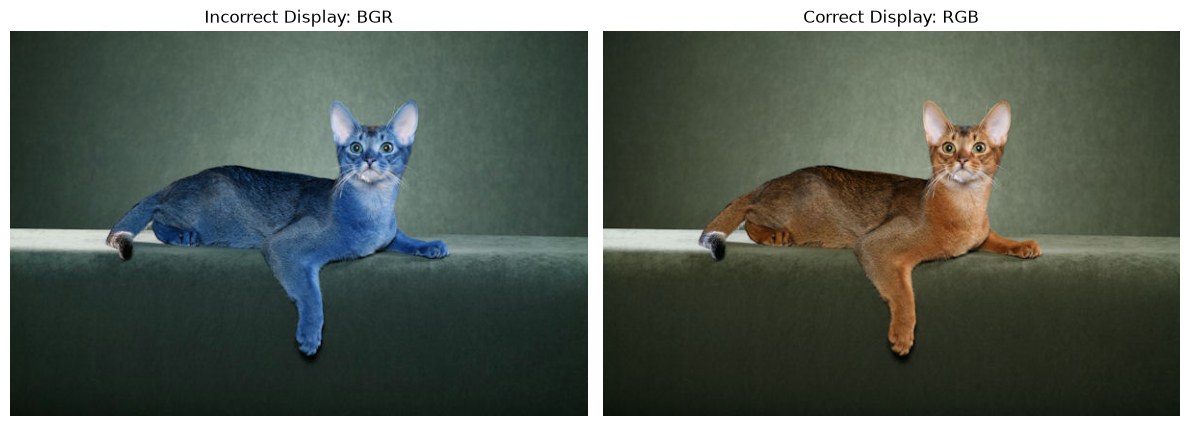

In [7]:
rgb_image = cv2.cvtColor(
    bgr_image,
    cv2.COLOR_BGR2RGB,
)

center_y = bgr_image.shape[0] // 2
center_x = bgr_image.shape[1] // 2

print(
    "Center pixel in BGR:",
    bgr_image[center_y, center_x],
)

print(
    "Center pixel in RGB:",
    rgb_image[center_y, center_x],
)

figure, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5),
)

axes[0].imshow(bgr_image)
axes[0].set_title("Incorrect Display: BGR")
axes[0].axis("off")

axes[1].imshow(rgb_image)
axes[1].set_title("Correct Display: RGB")
axes[1].axis("off")

plt.tight_layout()
plt.show()

<h2 style="color:#0072B2;">3.4 Resizing Images</h2>

The inspected dataset images have different widths and heights. A neural network cannot combine differently sized images into one numerical batch.

Resizing converts every image into a fixed target shape:

$$
(H_{\text{original}}, W_{\text{original}}, 3)
\longrightarrow
(224, 224, 3)
$$

OpenCV uses the following order when specifying the target size:

$$
(\text{Width},\text{Height})
$$

This differs from the NumPy image-shape order:

$$
(\text{Height},\text{Width},\text{Channels})
$$

In [8]:
resized_image = cv2.resize(
    rgb_image,
    TARGET_SIZE,
    interpolation=cv2.INTER_AREA,
)

print("Original shape:", rgb_image.shape)
print("Resized shape:", resized_image.shape)

assert resized_image.shape == (
    TARGET_SIZE[1],
    TARGET_SIZE[0],
    3,
)

Original shape: (400, 600, 3)
Resized shape: (224, 224, 3)


<h3 style="color:#009E73;">Does Direct Resizing Preserve Shape?</h3>

Direct resizing guarantees the required dimensions, but it does not preserve the original aspect ratio.

The original aspect ratio is:

$$
r_{\text{original}}
=
\frac{W_{\text{original}}}{H_{\text{original}}}
$$

If a rectangular image is forced into a square, objects may appear stretched or compressed. The following comparison visualizes this effect.

Original aspect ratio: 1.5
Resized aspect ratio: 1.0


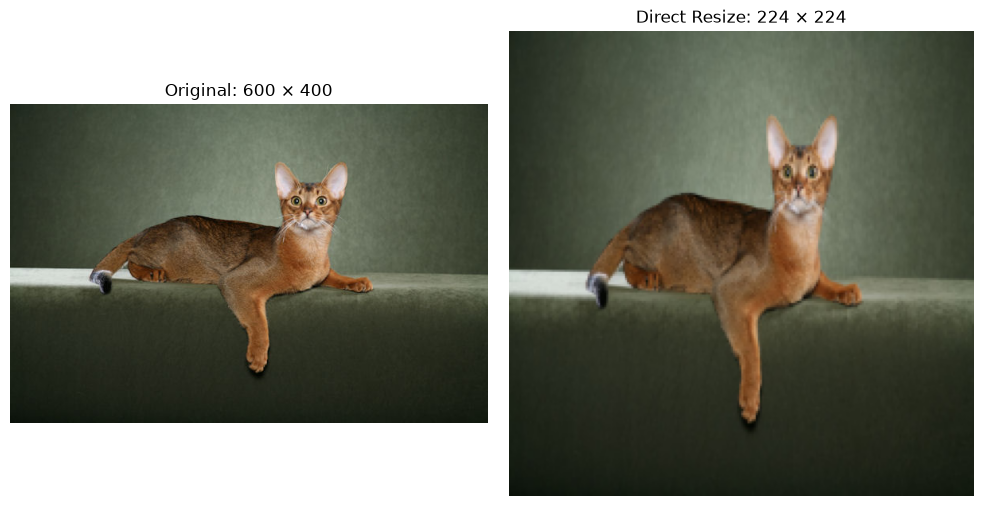

In [9]:
original_height, original_width = rgb_image.shape[:2]
resized_height, resized_width = resized_image.shape[:2]

original_ratio = original_width / original_height
resized_ratio = resized_width / resized_height

print("Original aspect ratio:", round(original_ratio, 3))
print("Resized aspect ratio:", round(resized_ratio, 3))

figure, axes = plt.subplots(
    1,
    2,
    figsize=(10, 5),
)

axes[0].imshow(rgb_image)
axes[0].set_title(
    f"Original: {original_width} × {original_height}"
)
axes[0].axis("off")

axes[1].imshow(resized_image)
axes[1].set_title(
    f"Direct Resize: {resized_width} × {resized_height}"
)
axes[1].axis("off")

plt.tight_layout()
plt.show()

<h2 style="color:#0072B2;">3.5 Resizing While Preserving Aspect Ratio</h2>

Direct resizing changes the original aspect ratio and may distort the object.

A safer approach is:

1. Calculate one scale factor for both dimensions.
2. Resize the image without changing its aspect ratio.
3. Add padding to reach the required target size.

The scale factor is:

$$
s =
\min
\left(
\frac{W_{\text{target}}}{W_{\text{original}}},
\frac{H_{\text{target}}}{H_{\text{original}}}
\right)
$$

The resized dimensions are:

$$
W_{\text{new}} = W_{\text{original}} \times s
$$

$$
H_{\text{new}} = H_{\text{original}} \times s
$$

The remaining space is filled with padding.

In [10]:
def resize_with_padding(
    image,
    target_size=(224, 224),
    padding_color=(0, 0, 0),
):
    target_width, target_height = target_size
    original_height, original_width = image.shape[:2]

    scale = min(
        target_width / original_width,
        target_height / original_height,
    )

    new_width = int(round(original_width * scale))
    new_height = int(round(original_height * scale))

    interpolation = (
        cv2.INTER_AREA
        if scale < 1
        else cv2.INTER_CUBIC
    )

    resized = cv2.resize(
        image,
        (new_width, new_height),
        interpolation=interpolation,
    )

    remaining_width = target_width - new_width
    remaining_height = target_height - new_height

    left = remaining_width // 2
    right = remaining_width - left
    top = remaining_height // 2
    bottom = remaining_height - top

    padded = cv2.copyMakeBorder(
        resized,
        top,
        bottom,
        left,
        right,
        borderType=cv2.BORDER_CONSTANT,
        value=padding_color,
    )

    resize_information = {
        "Original size": (original_width, original_height),
        "Resized content": (new_width, new_height),
        "Final size": (target_width, target_height),
        "Scale": scale,
        "Padding": {
            "top": top,
            "bottom": bottom,
            "left": left,
            "right": right,
        },
    }

    return padded, resize_information

In [11]:
padded_image, padding_information = resize_with_padding(
    rgb_image,
    target_size=TARGET_SIZE,
)

print("Original shape:", rgb_image.shape)
print("Direct-resize shape:", resized_image.shape)
print("Padded-image shape:", padded_image.shape)

print("\nResize information:")
for key, value in padding_information.items():
    print(f"{key}: {value}")

assert padded_image.shape == (
    TARGET_SIZE[1],
    TARGET_SIZE[0],
    3,
)

Original shape: (400, 600, 3)
Direct-resize shape: (224, 224, 3)
Padded-image shape: (224, 224, 3)

Resize information:
Original size: (600, 400)
Resized content: (224, 149)
Final size: (224, 224)
Scale: 0.37333333333333335
Padding: {'top': 37, 'bottom': 38, 'left': 0, 'right': 0}


<h3 style="color:#009E73;">Direct Resize versus Padding</h3>

Both methods produce an image with shape `(224, 224, 3)`.

However:

- Direct resize fills the complete square but changes the object's proportions.
- Aspect-ratio resize preserves the object shape and fills the remaining area with padding.

The same resizing method must later be used consistently for training, validation, testing, and inference.

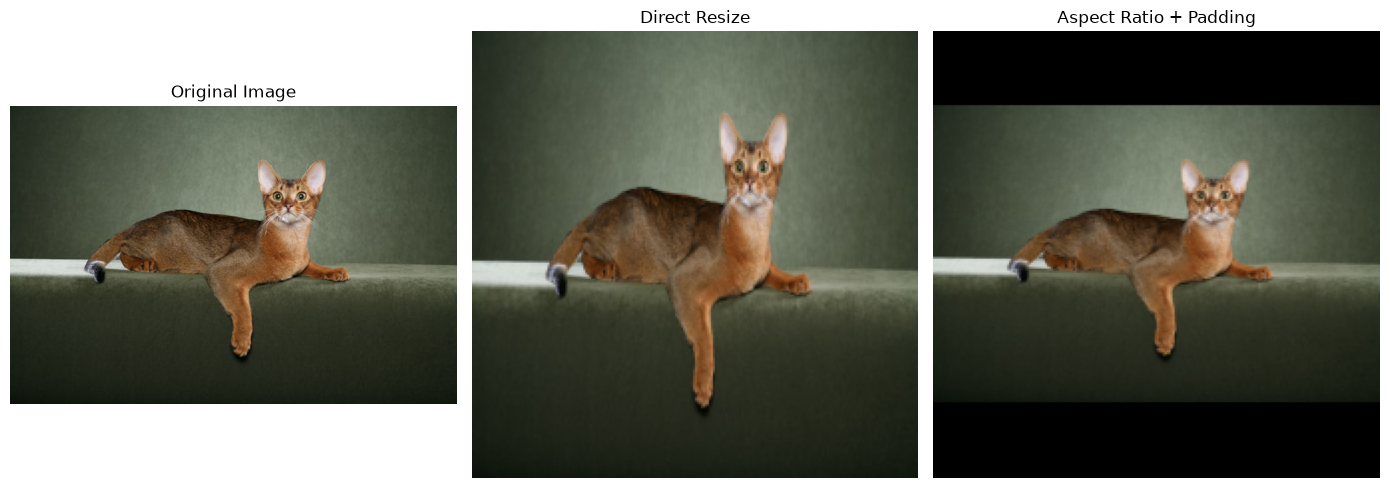

In [12]:
figure, axes = plt.subplots(
    1,
    3,
    figsize=(14, 5),
)

axes[0].imshow(rgb_image)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(resized_image)
axes[1].set_title("Direct Resize")
axes[1].axis("off")

axes[2].imshow(padded_image)
axes[2].set_title("Aspect Ratio + Padding")
axes[2].axis("off")

plt.tight_layout()
plt.show()

<h2 style="color:#0072B2;">3.6 Pixel Normalization</h2>

OpenCV reads image pixels as unsigned integers, usually within:

$$
0 \leq x \leq 255
$$

Large input values can make model training less numerically stable. A common normalization method divides every pixel by 255:

$$
x_{\text{normalized}}
=
\frac{x}{255}
$$

The resulting pixel range becomes:

$$
0.0 \leq x_{\text{normalized}} \leq 1.0
$$

Normalization changes the numerical representation of the image, not its visible content.

In [13]:
normalized_image = (
    padded_image.astype(np.float32) / 255.0
)

normalization_comparison = pd.DataFrame([
    {
        "Version": "Before normalization",
        "Data type": str(padded_image.dtype),
        "Minimum": padded_image.min(),
        "Maximum": padded_image.max(),
        "Mean": padded_image.mean(),
    },
    {
        "Version": "After normalization",
        "Data type": str(normalized_image.dtype),
        "Minimum": normalized_image.min(),
        "Maximum": normalized_image.max(),
        "Mean": normalized_image.mean(),
    },
])

display(normalization_comparison.round(4))

assert normalized_image.dtype == np.float32
assert normalized_image.min() >= 0.0
assert normalized_image.max() <= 1.0

,Version,Data type,Minimum,Maximum,Mean
0,Before normalization,uint8,0.0,236.0000,46.2821
1,After normalization,float32,0.0,0.9255,0.1815


<h3 style="color:#009E73;">Visual Effect of Normalization</h3>

Matplotlib understands both common image formats:

- Integer pixels between 0 and 255.
- Floating-point pixels between 0 and 1.

Therefore, both versions should look identical even though their numerical values and data types are different.

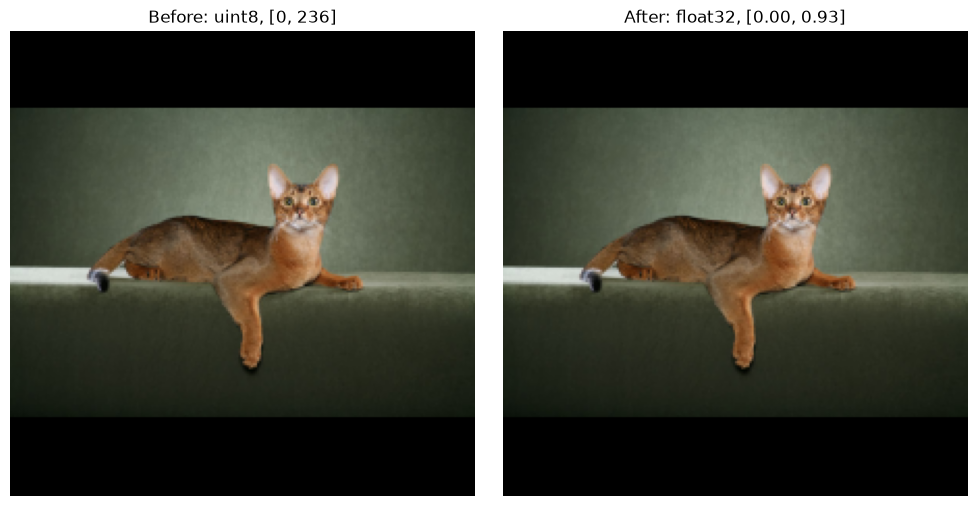

In [14]:
figure, axes = plt.subplots(
    1,
    2,
    figsize=(10, 5),
)

axes[0].imshow(padded_image)
axes[0].set_title(
    f"Before: {padded_image.dtype}, "
    f"[{padded_image.min()}, {padded_image.max()}]"
)
axes[0].axis("off")

axes[1].imshow(normalized_image)
axes[1].set_title(
    f"After: {normalized_image.dtype}, "
    f"[{normalized_image.min():.2f}, "
    f"{normalized_image.max():.2f}]"
)
axes[1].axis("off")

plt.tight_layout()
plt.show()

<h2 style="color:#0072B2;">3.7 Building a Reusable OpenCV Pipeline</h2>

The previous steps are combined into one reusable preprocessing function.

For every image, the function performs:

$$
\text{Read}
\rightarrow
\text{BGR to RGB}
\rightarrow
\text{Resize with Padding}
\rightarrow
\text{Normalize}
$$

The output is always a floating-point RGB image with shape `(224, 224, 3)` and pixel values between 0 and 1.

In [15]:
def preprocess_image_opencv(
    image_path,
    target_size=(224, 224),
):
    bgr_image = cv2.imread(str(image_path))

    if bgr_image is None:
        raise ValueError(
            f"OpenCV could not read the image: {image_path}"
        )

    rgb_image = cv2.cvtColor(
        bgr_image,
        cv2.COLOR_BGR2RGB,
    )

    resized_image, _ = resize_with_padding(
        rgb_image,
        target_size=target_size,
    )

    normalized_image = (
        resized_image.astype(np.float32) / 255.0
    )

    return normalized_image

<h3 style="color:#009E73;">Testing the Complete Pipeline</h3>

Six images with different original dimensions are processed using the same function.

After preprocessing, the images can be combined into one batch because they now share:

- The same width and height.
- The same RGB channel order.
- The same data type.
- The same normalized pixel range.

In [16]:
pipeline_test_indices = np.linspace(
    0,
    len(image_paths) - 1,
    6,
    dtype=int,
)

pipeline_test_paths = [
    image_paths[index]
    for index in pipeline_test_indices
]

processed_images = [
    preprocess_image_opencv(
        image_path,
        target_size=TARGET_SIZE,
    )
    for image_path in pipeline_test_paths
]

processed_batch = np.stack(processed_images)

print("Number of processed images:", len(processed_images))
print("Batch shape:", processed_batch.shape)
print("Batch data type:", processed_batch.dtype)
print("Minimum value:", processed_batch.min())
print("Maximum value:", processed_batch.max())

assert processed_batch.shape == (
    6,
    TARGET_SIZE[1],
    TARGET_SIZE[0],
    3,
)

assert processed_batch.dtype == np.float32
assert processed_batch.min() >= 0.0
assert processed_batch.max() <= 1.0

Number of processed images: 6
Batch shape: (6, 224, 224, 3)
Batch data type: float32
Minimum value: 0.0
Maximum value: 1.0


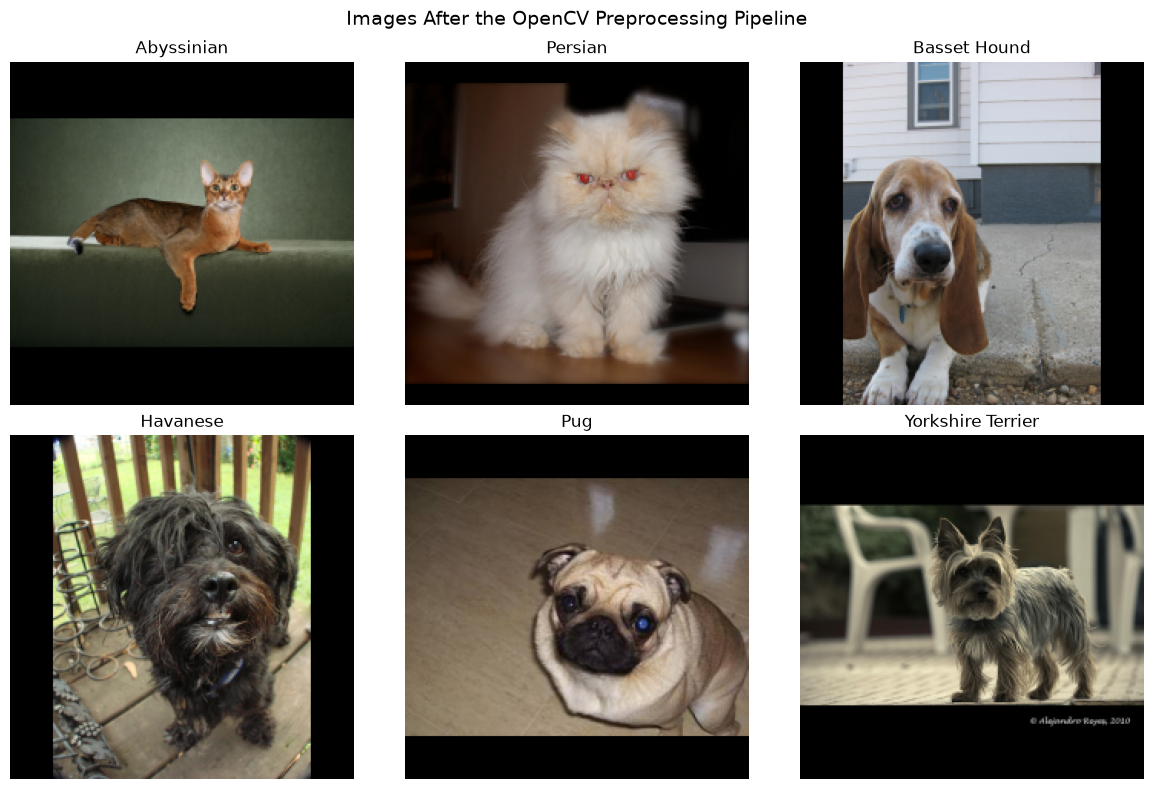

In [17]:
figure, axes = plt.subplots(
    2,
    3,
    figsize=(12, 8),
)

for axis, image, image_path in zip(
    axes.flat,
    processed_images,
    pipeline_test_paths,
):
    breed = (
        image_path.stem
        .rsplit("_", 1)[0]
        .replace("_", " ")
        .title()
    )

    axis.imshow(image)
    axis.set_title(breed)
    axis.axis("off")

plt.suptitle(
    "Images After the OpenCV Preprocessing Pipeline",
    fontsize=14,
)

plt.tight_layout()
plt.show()

<h2 style="color:#0072B2;">3.8 Building an Image-Augmentation Pipeline</h2>

Data augmentation creates slightly modified versions of training images without changing their labels.

The pipeline applies random:

- Horizontal flips.
- Small rotations.
- Width and height shifts.
- Zoom changes.
- Brightness changes.

This increases training diversity and helps reduce overfitting.

Augmentation is applied only to training images. Validation, test, and inference images use fixed preprocessing without random changes.

<h3 style="color:#009E73;">Selecting Safe Transformations</h3>

The transformations should remain realistic.

For pet images:

- Horizontal flipping is reasonable.
- Small rotations simulate camera-angle differences.
- Small shifts and zoom changes simulate different animal positions.
- Brightness changes simulate different lighting conditions.
- Vertical flipping is avoided because upside-down pets are uncommon.

The transformations must not change the correct breed label.

In [18]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

augmentation_generator = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=(0.8, 1.2),
    fill_mode="reflect",
    rescale=1.0 / 255.0,
)

print("Augmentation pipeline created.")

Augmentation pipeline created.


<h3 style="color:#009E73;">Visualizing Augmented Images</h3>

The same original image is passed through the augmentation pipeline several times.

Each call produces a different training example, while the breed label remains unchanged.

In [19]:
augmentation_input = np.expand_dims(
    padded_image,
    axis=0,
)

augmentation_iterator = augmentation_generator.flow(
    augmentation_input,
    batch_size=1,
    shuffle=False,
    seed=RANDOM_STATE,
)

augmented_images = [
    next(augmentation_iterator)[0]
    for _ in range(6)
]

augmented_batch = np.stack(augmented_images)

print("Augmented batch shape:", augmented_batch.shape)
print("Data type:", augmented_batch.dtype)
print("Minimum value:", augmented_batch.min())
print("Maximum value:", augmented_batch.max())

Augmented batch shape: (6, 224, 224, 3)
Data type: float32
Minimum value: 0.0
Maximum value: 1.0


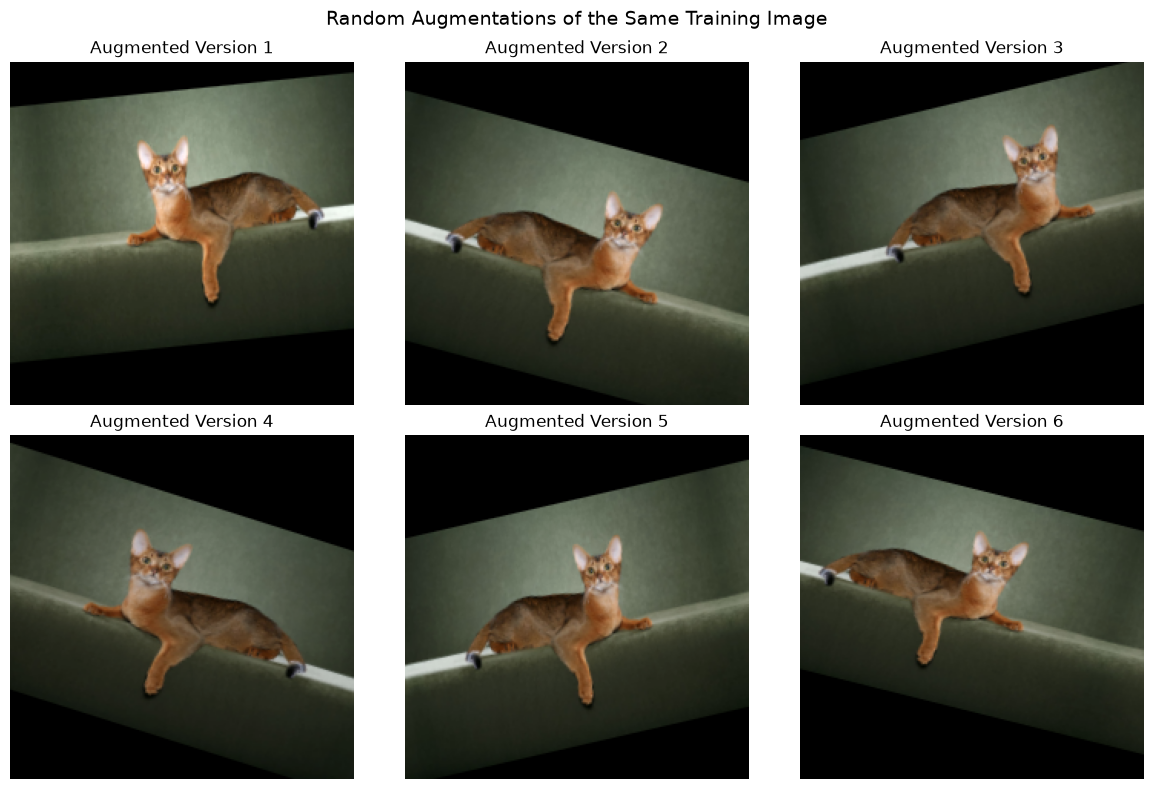

In [20]:
figure, axes = plt.subplots(
    2,
    3,
    figsize=(12, 8),
)

for index, (axis, image) in enumerate(
    zip(axes.flat, augmented_images),
    start=1,
):
    axis.imshow(image)
    axis.set_title(f"Augmented Version {index}")
    axis.axis("off")

plt.suptitle(
    "Random Augmentations of the Same Training Image",
    fontsize=14,
)

plt.tight_layout()
plt.show()

<h2 style="color:#0072B2;">3.9 Matching Preprocessing to MobileNetV2</h2>

Pretrained models expect images to be prepared in the same way used during their original training.

MobileNetV2 expects:

- RGB channel order.
- A fixed image size, commonly `(224, 224, 3)`.
- Floating-point pixel values.
- Pixel values transformed to approximately `[-1, 1]`.

Its preprocessing is:

$$
x_{\text{MobileNetV2}}
=
\frac{x}{127.5}-1
$$

Therefore, the general `[0,1]` normalization should not be applied before `preprocess_input`.

In [21]:
from tensorflow.keras.applications.mobilenet_v2 import (
    preprocess_input,
)

mobilenet_image = preprocess_input(
    padded_image.astype(np.float32).copy()
)

preprocessing_comparison = pd.DataFrame([
    {
        "Method": "Original OpenCV pixels",
        "Minimum": padded_image.min(),
        "Maximum": padded_image.max(),
        "Mean": padded_image.mean(),
    },
    {
        "Method": "General normalization",
        "Minimum": normalized_image.min(),
        "Maximum": normalized_image.max(),
        "Mean": normalized_image.mean(),
    },
    {
        "Method": "MobileNetV2 preprocessing",
        "Minimum": mobilenet_image.min(),
        "Maximum": mobilenet_image.max(),
        "Mean": mobilenet_image.mean(),
    },
])

display(preprocessing_comparison.round(4))

,Method,Minimum,Maximum,Mean
0,Original OpenCV pixels,0.0,236.0000,46.2821
1,General normalization,0.0,0.9255,0.1815
2,MobileNetV2 preprocessing,-1.0,0.8510,-0.6370


<h3 style="color:#009E73;">General versus Model-Specific Normalization</h3>

Two valid preprocessing methods have been demonstrated:

| Method | Pixel range | Intended use |
|---|---:|---|
| Divide by 255 | `[0, 1]` | General image models trained with this normalization |
| MobileNetV2 `preprocess_input` | `[-1, 1]` | A pretrained MobileNetV2 model |

Only one method should be used for a given model.

Applying both methods would incorrectly normalize the image twice.

In [22]:
def preprocess_image_for_mobilenet(
    image_path,
    target_size=(224, 224),
):
    bgr_image = cv2.imread(str(image_path))

    if bgr_image is None:
        raise ValueError(
            f"OpenCV could not read the image: {image_path}"
        )

    rgb_image = cv2.cvtColor(
        bgr_image,
        cv2.COLOR_BGR2RGB,
    )

    resized_image, _ = resize_with_padding(
        rgb_image,
        target_size=target_size,
    )

    model_input = preprocess_input(
        resized_image.astype(np.float32)
    )

    return model_input

In [23]:
mobilenet_batch = np.stack([
    preprocess_image_for_mobilenet(
        image_path,
        target_size=TARGET_SIZE,
    )
    for image_path in pipeline_test_paths
])

print("MobileNetV2 batch shape:", mobilenet_batch.shape)
print("Data type:", mobilenet_batch.dtype)
print("Minimum value:", mobilenet_batch.min())
print("Maximum value:", mobilenet_batch.max())

assert mobilenet_batch.shape == (
    6,
    224,
    224,
    3,
)

assert mobilenet_batch.min() >= -1.0
assert mobilenet_batch.max() <= 1.0

MobileNetV2 batch shape: (6, 224, 224, 3)
Data type: float32
Minimum value: -1.0
Maximum value: 1.0


<h3 style="color:#009E73;">Using MobileNetV2 as a Feature Extractor</h3>

MobileNetV2 was previously trained on the ImageNet dataset. Its convolutional base has already learned general visual patterns such as:

- Edges.
- Textures.
- Shapes.
- Object parts.

With `include_top=False`, the original ImageNet classifier is removed. The remaining model converts each image into learned feature maps that can later be used to train a new pet-breed classifier.

In [24]:
from tensorflow.keras.applications import MobileNetV2

mobilenet_base = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3),
)

mobilenet_base.trainable = False

sample_feature_map = mobilenet_base.predict(
    mobilenet_batch[:1],
    verbose=0,
)

print("Model input shape:", mobilenet_batch[:1].shape)
print("Feature-map shape:", sample_feature_map.shape)
print("Base model trainable:", mobilenet_base.trainable)
print("Base-model parameters:", f"{mobilenet_base.count_params():,}")

E0000 00:00:1788891577.705972  209551 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Model input shape: (1, 224, 224, 3)
Feature-map shape: (1, 7, 7, 1280)
Base model trainable: False
Base-model parameters: 2,257,984


<h2 style="color:#0072B2;">3.10 Testing the Pipeline with a Pretrained Classifier</h2>

A complete MobileNetV2 model pretrained on ImageNet is used to verify that the processed image batch is compatible with a real image classifier.

Unlike the previous feature extractor, this model keeps its original ImageNet classification layer and produces probabilities for 1,000 classes.

This is not yet a classifier trained on the 37 Oxford Pet breeds. The experiment only verifies the preprocessing pipeline and demonstrates pretrained inference.

In [25]:
from tensorflow.keras.applications.mobilenet_v2 import (
    decode_predictions,
)

imagenet_classifier = MobileNetV2(
    weights="imagenet",
    include_top=True,
    input_shape=(224, 224, 3),
)

imagenet_probabilities = imagenet_classifier.predict(
    mobilenet_batch,
    verbose=0,
)

print(
    "Prediction matrix shape:",
    imagenet_probabilities.shape,
)

print(
    "Probability sum for first image:",
    round(float(imagenet_probabilities[0].sum()), 4),
)

14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Prediction matrix shape: (6, 1000)
Probability sum for first image: 1.0


In [26]:
decoded_predictions = decode_predictions(
    imagenet_probabilities,
    top=3,
)

prediction_records = []

for image_path, image_predictions in zip(
    pipeline_test_paths,
    decoded_predictions,
):
    dataset_breed = (
        image_path.stem
        .rsplit("_", 1)[0]
        .replace("_", " ")
        .title()
    )

    for rank, (_, predicted_label, confidence) in enumerate(
        image_predictions,
        start=1,
    ):
        prediction_records.append({
            "Image": image_path.name,
            "Dataset breed": dataset_breed,
            "Rank": rank,
            "ImageNet prediction": predicted_label.replace(
                "_",
                " ",
            ).title(),
            "Confidence": confidence,
        })

pretrained_predictions_df = pd.DataFrame(
    prediction_records
)

display(
    pretrained_predictions_df.style.format({
        "Confidence": "{:.2%}",
    })
)

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 3us/step


,Image,Dataset breed,Rank,ImageNet prediction,Confidence
0,Abyssinian_1.jpg,Abyssinian,1,Grey Fox,12.13%
1,Abyssinian_1.jpg,Abyssinian,2,Red Fox,5.66%
2,Abyssinian_1.jpg,Abyssinian,3,Kit Fox,5.30%
3,Persian_183.jpg,Persian,1,Persian Cat,95.93%
4,Persian_183.jpg,Persian,2,Angora,0.28%
5,Persian_183.jpg,Persian,3,Teddy,0.06%
6,basset_hound_59.jpg,Basset Hound,1,Basset,94.26%
7,basset_hound_59.jpg,Basset Hound,2,Bloodhound,0.99%
8,basset_hound_59.jpg,Basset Hound,3,Beagle,0.35%
9,havanese_129.jpg,Havanese,1,Tibetan Terrier,40.54%


<h3 style="color:#009E73;">Interpreting the Pretrained Predictions</h3>

These predictions should not be treated as an evaluation of Oxford-IIIT Pet classification.

The Oxford dataset contains 37 specific breed labels, while the pretrained model uses the 1,000 ImageNet classes. Some labels overlap, but the two classification tasks are not identical.

The purpose of this experiment is to confirm that:

- OpenCV reads the images successfully.
- The images have the correct RGB order.
- Every image has shape `(224, 224, 3)`.
- The correct MobileNetV2 preprocessing is applied.
- The processed batch can produce valid model predictions.

<h2 style="color:#0072B2;">3.11 Saving Day 3 Results</h2>

The main preprocessing inspection and pretrained-model predictions are saved for later integration and reporting.

The saved outputs include:

- Sampled raw-image dimensions.
- The final preprocessing configuration.
- The top ImageNet predictions for the selected images.

The pretrained predictions demonstrate pipeline compatibility. They are not an evaluation of a custom Oxford Pet classifier.

In [27]:
day3_output_directory = Path(
    "outputs/week8_day3"
)

day3_output_directory.mkdir(
    parents=True,
    exist_ok=True,
)

image_inspection_df.to_csv(
    day3_output_directory
    / "raw_image_dimension_sample.csv",
    index=False,
)

pretrained_predictions_df.to_csv(
    day3_output_directory
    / "pretrained_imagenet_predictions.csv",
    index=False,
)

preprocessing_summary_df = pd.DataFrame([
    {
        "Dataset": "Oxford-IIIT Pet",
        "Image files": len(image_paths),
        "Classes": 37,
        "Target width": TARGET_SIZE[0],
        "Target height": TARGET_SIZE[1],
        "Color conversion": "BGR to RGB",
        "General normalization": "[0, 1]",
        "MobileNetV2 input range": "[-1, 1]",
        "Resize method": "Aspect ratio with padding",
        "Augmentation": (
            "rotation, shift, zoom, "
            "horizontal flip, brightness"
        ),
    }
])

preprocessing_summary_df.to_csv(
    day3_output_directory
    / "preprocessing_summary.csv",
    index=False,
)

display(preprocessing_summary_df)

print(
    "Day 3 results saved to:",
    day3_output_directory,
)

print("\nSaved files:")

for output_path in sorted(
    day3_output_directory.iterdir()
):
    print("-", output_path.name)

,Dataset,Image files,Classes,Target width,Target height,Color conversion,General normalization,MobileNetV2 input range,Resize method,Augmentation
0,Oxford-IIIT Pet,7390,37,224,224,BGR to RGB,"[0, 1]","[-1, 1]",Aspect ratio with padding,"rotation, shift, zoom, horizontal flip, bright..."


Day 3 results saved to: outputs/week8_day3

Saved files:
- preprocessing_summary.csv
- pretrained_imagenet_predictions.csv
- raw_image_dimension_sample.csv


<h2 style="color:#0072B2;">Day 3 Conclusion</h2>

Day 3 built a complete image-preprocessing workflow using OpenCV and connected it to a pretrained MobileNetV2 model.

### Main Findings

- The dataset contained 7,390 images from 37 pet breeds.
- Raw images had different widths and heights.
- OpenCV loaded images as BGR `uint8` arrays.
- BGR images were converted to RGB before visualization and model use.
- Images were resized to `(224, 224, 3)`.
- Aspect-ratio resizing with padding prevented object distortion.
- General normalization converted pixels from `[0, 255]` to `[0, 1]`.
- Data augmentation generated varied training examples using realistic transformations.
- MobileNetV2-specific preprocessing converted pixels to `[-1, 1]`.
- The frozen MobileNetV2 base converted one image into a feature map with shape `(7, 7, 1280)`.
- The complete pretrained model successfully produced ImageNet class probabilities.

### Final Preprocessing Pipelines

For a model trained with general normalization:

$$
\text{Read}
\rightarrow
\text{BGR to RGB}
\rightarrow
\text{Resize}
\rightarrow
[0,1]
$$

For pretrained MobileNetV2:

$$
\text{Read}
\rightarrow
\text{BGR to RGB}
\rightarrow
\text{Resize}
\rightarrow
\text{MobileNetV2 preprocess\_input}
$$

### Final Decision

Image preprocessing must match the model's original training configuration. General normalization and MobileNetV2 preprocessing are both valid, but they must not be applied together.

The completed pipeline can now process new images consistently and provide model-ready inputs for transfer learning or pretrained inference.